In [1]:
from tempfile import TemporaryDirectory

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf
from scarf.tools.repack_zarr import repack_store

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
analysis_directory = TemporaryDirectory()
repacked_counts = f"{analysis_directory.name}/counts.zarr"
repack_store(f"{dataset}/data.zarr", repacked_counts, nthreads=2)
ds = scarf.mount_datastore(
    repacked_counts,
    at=f"{analysis_directory.name}/analysis.zarr",
    nthreads=4,
    default_assay="RNA",
)

cell_selection = ds.snapshot_cell_selection("I")
features = ds.select_hvgs(cell_selection, top_n=2000, show_plot=False)
normalized = ds.run_normalization(cell_selection, features)
pca = ds.run_pca(normalized, dims=15)
ann = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann, k=11)
graph = ds.build_connectivity_map(neighbors)

annotations = np.asarray(ds.cells.fetch("clusters", key="I"))
source = annotations == "Ductal"
sink = np.isin(annotations, ["Alpha", "Beta", "Delta"])
source_sink_vector = np.zeros(len(annotations), dtype=float)
source_sink_vector[source] = 1.0 / int(source.sum())
source_sink_vector[sink] = -1.0 / int(sink.sum())

pseudotime_ref = ds.run_pseudotime_scoring(graph, ss_vec=source_sink_vector)
pseudotime = ds.load_pseudotime_scoring(pseudotime_ref)
sink_labels_ref = ds.run_leiden_clustering(graph, resolution=1.0)
sink_labels = np.asarray(ds.load_artifact(sink_labels_ref)["values"][:])

Downloading bucket files: 43423201 / 43423201 complete

Downloading bytes: 43423201 / 43423201 complete

Repacking RNA/counts: 1 / 1 complete

Repacking RNA/artifacts/connectivity_map//edges: 1 / 1 complete

Repacking RNA/artifacts/reduction//loadings: 1 / 1 complete

...

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

In [2]:
valid_frame = pd.DataFrame(
    {
        "label": sink_labels[pseudotime.valid],
        "pseudotime": pseudotime.values[pseudotime.valid],
    }
)
terminal_labels = (
    valid_frame.groupby("label")["pseudotime"].mean().nlargest(2).index.tolist()
)
terminal_labels

[14, 4]

In [3]:
fate_ref = ds.run_fate_mapping(
    pseudotime_ref,
    sink_labels_ref,
    sinks=terminal_labels,
)
fate = ds.load_fate_mapping(fate_ref)
{
    "artifact": fate.ref,
    "pseudotime": fate.pseudotime,
    "sink labels": fate.sink_labels,
    "valid cells": int(fate.valid.sum()),
}

{'artifact': ArtifactRef(assay='RNA', kind='fate_map', artifact_id='1d1c23d05463...'),
 'pseudotime': ArtifactRef(assay='RNA', kind='pseudotime', artifact_id='e7a6ab3d1513...'),
 'sink labels': (14, 4),
 'valid cells': 3696}

In [4]:
valid_probabilities = fate.values[fate.valid]
pd.DataFrame(
    valid_probabilities,
    columns=[str(label) for label in fate.sink_labels],
).describe().loc[["min", "50%", "max"]]

,14,4
min,0.000000,0.000000
50%,0.635195,0.364805
max,1.000000,1.000000


In [5]:
pd.Series(
    {
        "minimum": float(valid_probabilities.min()),
        "maximum": float(valid_probabilities.max()),
        "maximum row-sum error": float(
            np.abs(valid_probabilities.sum(axis=1) - 1.0).max()
        ),
    }
)

minimum                  0.0
maximum                  1.0
maximum row-sum error    0.0
dtype: float64

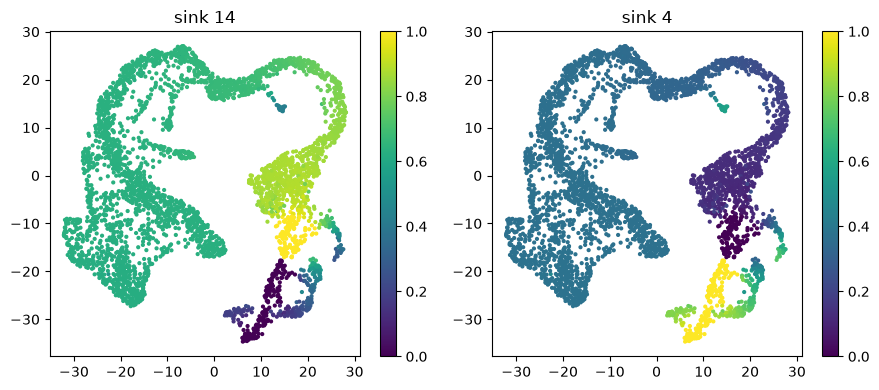

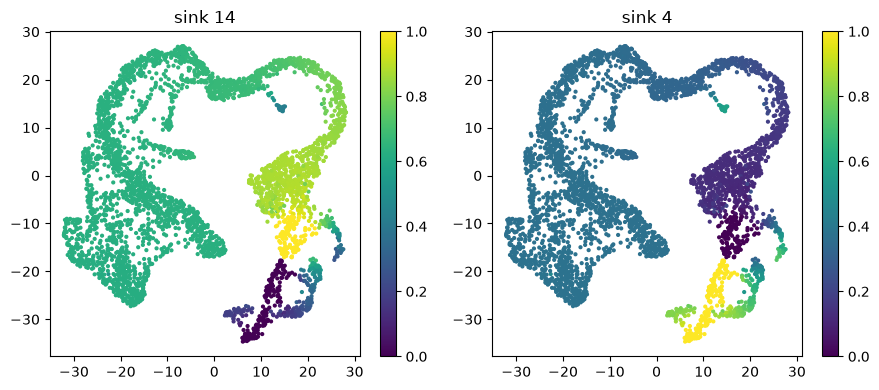

In [6]:
umap = ds.cells.to_pandas_dataframe(["RNA_UMAP1", "RNA_UMAP2"], key="I")
figure, axes = plt.subplots(1, len(fate.sink_labels), figsize=(9, 4))
for axis, index, label in zip(
    np.atleast_1d(axes),
    range(len(fate.sink_labels)),
    fate.sink_labels,
    strict=True,
):
    points = axis.scatter(
        umap.loc[fate.valid, "RNA_UMAP1"],
        umap.loc[fate.valid, "RNA_UMAP2"],
        c=fate.values[fate.valid, index],
        s=4,
    )
    axis.set_title(f"sink {label}")
    figure.colorbar(points, ax=axis)
figure.tight_layout()
figure